# Learning When to Read: Reinforcement Learning for Selective Context Use in Transformer-Based Scientific Text Categorization

This project studies whether an NLP classifier can predict ArXiv paper categories accurately while avoiding unnecessary abstract processing. We build a balanced dataset of 6000 recent ArXiv papers from six primary categories (`cs.CL`, `cs.LG`, `cs.CV`, `cs.AI`, `cs.NE`, and `stat.ML`) and compare title-only classification against title-plus-abstract classification. The supervised stage evaluates a TF-IDF + Linear SVM baseline and a transformer pool consisting of SciBERT, DistilBERT, and MiniLM.

The strongest classifier in the final run is **SciBERT using title + abstract**, with test accuracy **0.752** and macro F1 **0.750**. Title-only SciBERT reaches test accuracy **0.696**, showing that abstracts provide a clear performance gain but require substantially longer inputs. To make this trade-off adaptive, we train a  policy-gradient RL agent that observes the title-only model's class-probability vector plus confidence summaries: top-1 probability, top-2 probability, probability margin, and prediction entropy. The agent chooses between using the title-only prediction and reading the abstract, with reward defined as correctness minus an abstract-reading cost.

The learned RL policy reads abstracts for **15.2%** of test papers, saves **84.8%** of abstract reads relative to always using abstracts, and achieves test accuracy **0.723** with average reward **0.701**. The result shows a cost-aware classification pipeline that preserves much of the benefit of abstract information while usually relying on the cheaper title-only model. Data, checkpoints, tables, and figures are cached under `data/` and `results/` so the notebook can be rerun or resumed efficiently.


## 1. Setup and Configuration

In [36]:
from __future__ import annotations

import json 
import math
import random
import re
import subprocess
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_DIR = DATA_DIR / "splits"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

for directory in [RAW_DIR, PROCESSED_DIR, SPLIT_DIR, FIGURES_DIR, TABLES_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CATEGORIES = ["cs.CL", "cs.LG", "cs.CV", "cs.AI", "cs.NE", "stat.ML"]
PAPERS_PER_CATEGORY = 1000
RAW_DATA_PATH = RAW_DIR / "arxiv_1000_per_category.csv"
PROCESSED_DATA_PATH = PROCESSED_DIR / "arxiv_processed.csv"

TRANSFORMER_MODELS = {
    "SciBERT": "allenai/scibert_scivocab_uncased",
    "DistilBERT": "distilbert-base-uncased",
    "MiniLM": "microsoft/MiniLM-L12-H384-uncased",
}
TRANSFORMER_EPOCHS = 4
TRANSFORMER_BATCH_SIZE = 32
TRANSFORMER_LR = 2e-5
TRANSFORMER_WEIGHT_DECAY = 0.01
TITLE_MAX_LENGTH = 64
TITLE_ABSTRACT_MAX_LENGTH = 256
SAVE_TRANSFORMER_CHECKPOINTS = True
KEEP_TRANSFORMER_MODELS_IN_MEMORY = False
TRANSFORMER_EARLY_STOPPING_PATIENCE = 2

ABSTRACT_COST = 0.15
THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90]
RL_EPOCHS = 400
RL_BATCH_SIZE = 128
RL_LR = 1e-3
RL_ENTROPY_COEF = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Project directory:", PROJECT_DIR)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0)) 


Project directory: /home/dd/code/final_nlp_project
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


## 2. Load Presaved ArXiv Dataset

The dataset consists of most recent ArXiv papers from each of six computer science and statistics categories. Each paper contributes a title, abstract, publication metadata, and primary ArXiv category label. The dataset was collected from Arxiv API at May 21th 2026.

To keep the experiment reproducible, the notebook uses a cached CSV when available. If the dataset has not been collected yet, it runs the official-API downloader script, which saves progress incrementally so collection can resume after interruptions.


In [37]:
def normalize_text(text: str | None) -> str:
    """Normalize text fields loaded from the cached ArXiv CSV."""
    if text is None or pd.isna(text):
        return ""
    text = str(text).replace("\u00a0", " ")
    return re.sub(r"\s+", " ", text).strip()


def ensure_arxiv_csv(path: Path = RAW_DATA_PATH) -> None:
    """Use the cached dataset when present; otherwise run the downloader script."""
    if path.exists():
        print(f"Found cached ArXiv CSV: {path}")
        return

    script_path = PROJECT_DIR / "scripts" / "download_arxiv_dataset.py"
    if not script_path.exists():
        raise FileNotFoundError(f"Missing downloader script: {script_path}")

    print(f"Cached ArXiv CSV not found at {path}")
    print(f"Running downloader script: {script_path}")
    command = [
        sys.executable,
        str(script_path),
        "--output",
        str(path),
        "--progress",
        str(RAW_DIR / "arxiv_1000_per_category_progress.json"),
        "--papers-per-category",
        str(PAPERS_PER_CATEGORY),
        "--categories",
        *CATEGORIES,
    ]
    subprocess.run(command, check=True, cwd=PROJECT_DIR)


def load_presaved_arxiv_csv(path: Path = RAW_DATA_PATH) -> pd.DataFrame:
    """Load the 1000-per-category ArXiv dataset for downstream experiments."""
    ensure_arxiv_csv(path)
    required_columns = ["paper_id", "title", "abstract", "category", "published", "updated"]

    df = pd.read_csv(path)
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise ValueError(f"Cached CSV is missing required columns: {missing}")

    df = df[required_columns].copy()
    for column in required_columns:
        df[column] = df[column].map(normalize_text)

    before = len(df)
    df = df[df["category"].isin(CATEGORIES)].copy()
    df = df.drop_duplicates(subset="paper_id", keep="first")
    df = df[(df["paper_id"] != "") & (df["title"] != "") & (df["abstract"] != "")].copy()
    df = df.sort_values(["category", "published"], ascending=[True, False]).reset_index(drop=True)

    counts = df["category"].value_counts().reindex(CATEGORIES, fill_value=0)
    print(f"Loaded ArXiv CSV: {path}")
    print(f"Rows before cleaning: {before}")
    print(f"Rows after cleaning/deduplication: {len(df)}")
    print("Category counts:")
    display(counts.to_frame("rows"))

    short = counts[counts < PAPERS_PER_CATEGORY]
    if len(short):
        print("Warning: these categories are below target and downstream splits will use what is available:")
        display(short.to_frame("rows"))
    else:
        print(f"All categories have at least {PAPERS_PER_CATEGORY} rows.")

    return df


raw_df = load_presaved_arxiv_csv()
display(raw_df.head())


Found cached ArXiv CSV: /home/dd/code/final_nlp_project/data/raw/arxiv_1000_per_category.csv
Loaded ArXiv CSV: /home/dd/code/final_nlp_project/data/raw/arxiv_1000_per_category.csv
Rows before cleaning: 6000
Rows after cleaning/deduplication: 6000
Category counts:


,rows
category,
cs.CL,1000
cs.LG,1000
cs.CV,1000
cs.AI,1000
cs.NE,1000
stat.ML,1000


All categories have at least 1000 rows.


,paper_id,title,abstract,category,published,updated
0,2605.21482,DeepWeb-Bench: A Deep Research Benchmark Deman...,"Deep research, in which an agent searches the ...",cs.AI,2026-05-20T17:59:03Z,2026-05-20T17:59:03Z
1,2605.21481,AiraXiv: An AI-Driven Open-Access Platform for...,Recent advances in artificial intelligence (AI...,cs.AI,2026-05-20T17:59:03Z,2026-05-20T17:59:03Z
2,2605.21458,Mind the Sim-to-Real Gap & Think Like a Scientist,Suppose a planner has a pre-trained simulator ...,cs.AI,2026-05-20T17:48:14Z,2026-05-20T17:48:14Z
3,2605.21427,PALS: Power-Aware LLM Serving for Mixture-of-E...,Large language model (LLM) inference has becom...,cs.AI,2026-05-20T17:19:20Z,2026-05-20T17:19:20Z
4,2605.21413,Teaching AI Through Benchmark Construction: Qu...,"As AI becomes part of everyday learning, many ...",cs.AI,2026-05-20T17:09:56Z,2026-05-20T17:09:56Z


## 3. Cleaning, Validation, and Stratified Split

This stage prepares and turns the raw ArXiv export into a controlled classification dataset.


In [38]:
def preprocess_raw_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    required = ["paper_id", "title", "abstract", "category", "published", "updated"]
    missing_columns = sorted(set(required) - set(raw_df.columns))
    if missing_columns:
        raise ValueError(f"Raw data is missing required columns: {missing_columns}")

    df = raw_df[required].copy()
    for col in ["paper_id", "title", "abstract", "category", "published", "updated"]:
        df[col] = df[col].astype(str).map(normalize_text)

    df = df[df["category"].isin(CATEGORIES)].copy()
    df = df.drop_duplicates(subset="paper_id", keep="first")
    df = df[(df["title"] != "") & (df["abstract"] != "") & (df["category"] != "")].copy()

    balanced_parts = []
    shortages = {}
    for category in CATEGORIES:
        part = df[df["category"] == category].sort_values("published", ascending=False)
        if len(part) < PAPERS_PER_CATEGORY:
            shortages[category] = len(part)
        balanced_parts.append(part.head(PAPERS_PER_CATEGORY))
    clean_df = pd.concat(balanced_parts, ignore_index=True)
    clean_df = clean_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    if shortages:
        print("Warning: fewer than target rows were available after cleaning:", shortages)
    return clean_df


def make_splits(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=SEED,
        stratify=df["category"],
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_df["category"],
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )

processed_df = preprocess_raw_data(raw_df)
processed_df.to_csv(PROCESSED_DATA_PATH, index=False)

if len(processed_df) < len(CATEGORIES) * PAPERS_PER_CATEGORY:
    print(f"Processed data has {len(processed_df)} rows, less than requested {len(CATEGORIES) * PAPERS_PER_CATEGORY}.")
else:
    print(f"Processed data has the requested {len(processed_df)} rows.")

assert processed_df[["paper_id", "title", "abstract", "category"]].isna().sum().sum() == 0
assert (processed_df["title"].str.len() > 0).all()
assert (processed_df["abstract"].str.len() > 0).all()
assert processed_df["paper_id"].is_unique

train_df, val_df, test_df = make_splits(processed_df)
train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "validation.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Split sizes:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Train category counts")
display(train_df["category"].value_counts().sort_index())
print("Validation category counts")
display(val_df["category"].value_counts().sort_index())
print("Test category counts")
display(test_df["category"].value_counts().sort_index())


Processed data has the requested 6000 rows.
Split sizes: {'train': 4200, 'validation': 900, 'test': 900}
Train category counts


category
cs.AI      700
cs.CL      700
cs.CV      700
cs.LG      700
cs.NE      700
stat.ML    700
Name: count, dtype: int64

Validation category counts


category
cs.AI      150
cs.CL      150
cs.CV      150
cs.LG      150
cs.NE      150
stat.ML    150
Name: count, dtype: int64

Test category counts


category
cs.AI      150
cs.CL      150
cs.CV      150
cs.LG      150
cs.NE      150
stat.ML    150
Name: count, dtype: int64

## 4. Shared Evaluation Helpers

All models are evaluated under the same classification proce. The notebook defines two input views of each paper: a cheap title-only view and a richer title-plus-abstract view.

Using shared metrics makes the comparison fair across classical baselines, transformers, and the downstream RL policy. Macro F1 is treated as a primary metric because the project cares about balanced performance across all six categories.


In [39]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["category"])
y_val = label_encoder.transform(val_df["category"])
y_test = label_encoder.transform(test_df["category"])
label_names = list(label_encoder.classes_)
num_labels = len(label_names)


def make_text(df: pd.DataFrame, input_mode: str) -> list[str]:
    if input_mode == "title":
        return df["title"].tolist()
    if input_mode == "title_abstract":
        return (df["title"] + " [SEP] " + df["abstract"]).tolist()
    raise ValueError(f"Unknown input mode: {input_mode}")


def prediction_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def add_result(results: list[dict[str, Any]], model_name: str, input_mode: str, split: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, Any]:
    row = {"model": model_name, "input": input_mode, "split": split}
    row.update(prediction_metrics(y_true, y_pred))
    results.append(row)
    return row


def display_classification_report(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    print(title)
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

baseline_results: list[dict[str, Any]] = []
prediction_store: dict[tuple[str, str], dict[str, Any]] = {}


## 5. Classical Baseline: TF-IDF + Linear SVM

The Linear SVM baseline establishes how far a strong non-neural text classifier can go on this task. It is included as a lightweight reference point against the transformer models.

Training the SVM on both input views also measures the value of abstracts before any RL is introduced. This gives a simple supervised estimate of how much accuracy is gained by paying for the longer input.


In [40]:
def train_classical_model(model_name: str, estimator: Any, input_mode: str, has_proba: bool) -> None:
    print(f"Training {model_name} on {input_mode}")
    pipeline = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=50_000,
                    sublinear_tf=True,
                ),
            ),
            ("clf", clone(estimator)),
        ]
    )
    x_train = make_text(train_df, input_mode)
    x_val = make_text(val_df, input_mode)
    x_test = make_text(test_df, input_mode)
    pipeline.fit(x_train, y_train)

    val_pred = pipeline.predict(x_val)
    test_pred = pipeline.predict(x_test)
    add_result(baseline_results, model_name, input_mode, "validation", y_val, val_pred)
    add_result(baseline_results, model_name, input_mode, "test", y_test, test_pred)

    store = {
        "model": pipeline,
        "val_pred": np.asarray(val_pred),
        "test_pred": np.asarray(test_pred),
    }
    if has_proba:
        store["val_proba"] = pipeline.predict_proba(x_val)
        store["test_proba"] = pipeline.predict_proba(x_test)
    prediction_store[(model_name, input_mode)] = store


linear_svm = LinearSVC(class_weight="balanced", random_state=SEED)

for input_mode in ["title", "title_abstract"]:
    train_classical_model("TF-IDF + Linear SVM", linear_svm, input_mode, has_proba=False)

classical_results_df = pd.DataFrame(baseline_results).sort_values(["split", "macro_f1"], ascending=[True, False])
display(classical_results_df)
classical_results_df.to_csv(TABLES_DIR / "classical_baseline_results.csv", index=False)


Training TF-IDF + Linear SVM on title
Training TF-IDF + Linear SVM on title_abstract


,model,input,split,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
3,TF-IDF + Linear SVM,title_abstract,test,0.748889,0.741974,0.741974,0.740474,0.748889
1,TF-IDF + Linear SVM,title,test,0.633333,0.633645,0.633645,0.634565,0.633333
2,TF-IDF + Linear SVM,title_abstract,validation,0.744444,0.737715,0.737715,0.736041,0.744444
0,TF-IDF + Linear SVM,title,validation,0.626667,0.625437,0.625437,0.626034,0.626667


## 6. Transformer models tests


In [41]:
for model_label, model_name in TRANSFORMER_MODELS.items():
    print(f"Smoke test: {model_label} ({model_name})")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    smoke_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
    smoke_batch = tokenizer(
        make_text(train_df.head(2), "title"),
        padding=True,
        truncation=True,
        max_length=TITLE_MAX_LENGTH,
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        smoke_output = smoke_model(**smoke_batch)
    print("  logits shape:", tuple(smoke_output.logits.shape))
    del tokenizer, smoke_model, smoke_batch, smoke_output
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Smoke test: SciBERT (allenai/scibert_scivocab_uncased)


/home/dd/miniconda3/envs/llm_hw2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at allenai/scibert_scivocab_uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTrain

  logits shape: (2, 6)
Smoke test: DistilBERT (distilbert-base-uncased)


Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias', 'classifier.we

  logits shape: (2, 6)
Smoke test: MiniLM (microsoft/MiniLM-L12-H384-uncased)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  logits shape: (2, 6)


## 7. Transformer Model Pool Fine-Tuning

The main supervised experiment compares a small transformer pool: SciBERT, DistilBERT, and MiniLM. SciBERT is expected to be strongest because it is pretrained on scientific text, while the other models test whether smaller general-domain transformers are competitive.

Each transformer is trained on title-only and title-plus-abstract inputs.

In [42]:
transformer_history: list[dict[str, Any]] = []


def transformer_checkpoint_dir(model_label: str, input_mode: str) -> Path:
    safe_name = re.sub(r"[^a-z0-9]+", "_", model_label.lower()).strip("_")
    return CHECKPOINT_DIR / "transformers" / f"{safe_name}_{input_mode}"


class TextClassificationDataset(Dataset):
    def __init__(self, texts: list[str], labels: np.ndarray, tokenizer: Any, max_length: int):
        self.texts = texts
        self.labels = labels.astype(np.int64)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        encoded = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {key: value.squeeze(0) for key, value in encoded.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def evaluate_transformer(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluate", leave=False):
            labels = batch.pop("labels").to(device)
            batch = {key: value.to(device) for key, value in batch.items()}
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                outputs = model(**batch)
            all_logits.append(outputs.logits.detach().cpu())
            all_labels.append(labels.detach().cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    return logits, labels


def train_transformer_model(model_label: str, model_name: str, input_mode: str) -> None:
    max_length = TITLE_MAX_LENGTH if input_mode == "title" else TITLE_ABSTRACT_MAX_LENGTH
    print(f"Fine-tuning {model_label} on {input_mode} with max_length={max_length}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = TextClassificationDataset(make_text(train_df, input_mode), y_train, tokenizer, max_length)
    val_dataset = TextClassificationDataset(make_text(val_df, input_mode), y_val, tokenizer, max_length)
    test_dataset = TextClassificationDataset(make_text(test_df, input_mode), y_test, tokenizer, max_length)

    train_loader = DataLoader(train_dataset, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=TRANSFORMER_BATCH_SIZE * 2, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=TRANSFORMER_BATCH_SIZE * 2, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=TRANSFORMER_LR, weight_decay=TRANSFORMER_WEIGHT_DECAY)
    total_steps = len(train_loader) * TRANSFORMER_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(total_steps * 0.1)),
        num_training_steps=total_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val_macro_f1 = -1.0
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0
    min_delta = 1e-4

    for epoch in range(1, TRANSFORMER_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"{model_label} {input_mode} epoch {epoch}"):
            labels = batch.pop("labels").to(device)
            batch = {key: value.to(device) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                outputs = model(**batch, labels=labels)
                loss = outputs.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running_loss += float(loss.detach().cpu())

        val_logits, _ = evaluate_transformer(model, val_loader)
        val_pred = val_logits.argmax(axis=1)
        val_metrics = prediction_metrics(y_val, val_pred)
        val_macro_f1 = val_metrics["macro_f1"]
        epoch_loss = running_loss / len(train_loader)
        transformer_history.append(
            {
                "model": model_label,
                "input": input_mode,
                "epoch": epoch,
                "train_loss": epoch_loss,
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
            }
        )
        print(
            f"Epoch {epoch}: train_loss={epoch_loss:.4f}, "
            f"val_accuracy={val_metrics['accuracy']:.4f}, "
            f"val_macro_f1={val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_val_macro_f1 + min_delta:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            epochs_without_improvement += 1
            print(
                f"No validation macro-F1 improvement for {epochs_without_improvement}/"
                f"{TRANSFORMER_EARLY_STOPPING_PATIENCE} epoch(s)."
            )
            if epochs_without_improvement >= TRANSFORMER_EARLY_STOPPING_PATIENCE:
                print(f"Early stopping {model_label} {input_mode} at epoch {epoch}; best epoch was {best_epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(
            f"Restored best {model_label} {input_mode} checkpoint from epoch {best_epoch} "
            f"with val_macro_f1={best_val_macro_f1:.4f}."
        )

    val_logits, _ = evaluate_transformer(model, val_loader)
    test_logits, _ = evaluate_transformer(model, test_loader)
    val_proba = torch.softmax(torch.tensor(val_logits), dim=1).numpy()
    test_proba = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
    val_pred = val_proba.argmax(axis=1)
    test_pred = test_proba.argmax(axis=1)

    add_result(baseline_results, model_label, input_mode, "validation", y_val, val_pred)
    add_result(baseline_results, model_label, input_mode, "test", y_test, test_pred)
    prediction_store[(model_label, input_mode)] = {
        "model": model if KEEP_TRANSFORMER_MODELS_IN_MEMORY else None,
        "val_pred": val_pred,
        "test_pred": test_pred,
        "val_proba": val_proba,
        "test_proba": test_proba,
    }

    if SAVE_TRANSFORMER_CHECKPOINTS:
        out_dir = transformer_checkpoint_dir(model_label, input_mode)
        out_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(out_dir)
        tokenizer.save_pretrained(out_dir)
        metadata = {
            "model_label": model_label,
            "base_model_name": model_name,
            "input_mode": input_mode,
            "max_length": max_length,
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
            "label_names": label_names,
        }
        (out_dir / "training_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
        print(f"Saved best {model_label} {input_mode} weights to {out_dir}")

    if not KEEP_TRANSFORMER_MODELS_IN_MEMORY:
        del model
    del tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


for model_label, model_name in TRANSFORMER_MODELS.items():
    for input_mode in ["title", "title_abstract"]:
        train_transformer_model(model_label, model_name, input_mode)

baseline_results_df = pd.DataFrame(baseline_results).sort_values(["split", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
display(baseline_results_df)
baseline_results_df.to_csv(TABLES_DIR / "baseline_results.csv", index=False)

transformer_history_df = pd.DataFrame(transformer_history)
print("Transformer training history")
display(transformer_history_df)
transformer_history_df.to_csv(TABLES_DIR / "transformer_training_history.csv", index=False)
# Keep the old filename for compatibility with earlier analysis cells.
transformer_history_df.to_csv(TABLES_DIR / "scibert_training_history.csv", index=False)


Fine-tuning SciBERT on title with max_length=64


Some weights of the model checkpoint at allenai/scibert_scivocab_uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification we

SciBERT title epoch 1:   0%|          | 0/132 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1: train_loss=1.3330, val_accuracy=0.6633, val_macro_f1=0.6450


...

Evaluate:   0%|          | 0/15 [00:00<?, ?it/s]

Saved best MiniLM title_abstract weights to /home/dd/code/final_nlp_project/results/checkpoints/transformers/minilm_title_abstract


,model,input,split,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,SciBERT,title_abstract,test,0.752222,0.749680,0.749680,0.750997,0.752222
1,TF-IDF + Linear SVM,title_abstract,test,0.748889,0.741974,0.741974,0.740474,0.748889
2,DistilBERT,title_abstract,test,0.716667,0.709482,0.709482,0.708168,0.716667
3,SciBERT,title,test,0.695556,0.695848,0.695848,0.697497,0.695556
4,DistilBERT,title,test,0.662222,0.657557,0.657557,0.655276,0.662222
5,TF-IDF + Linear SVM,title,test,0.633333,0.633645,0.633645,0.634565,0.633333
6,MiniLM,title_abstract,test,0.652222,0.630189,0.630189,0.635250,0.652222
7,MiniLM,title,test,0.538889,0.467658,0.467658,0.443242,0.538889
8,SciBERT,title_abstract,validation,0.767778,0.762486,0.762486,0.766435,0.767778
9,TF-IDF + Linear SVM,title_abstract,validation,0.744444,0.737715,0.737715,0.736041,0.744444


Transformer training history


,model,input,epoch,train_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,SciBERT,title,1,1.333009,0.663333,0.645040,0.645040
1,SciBERT,title,2,0.838430,0.683333,0.676343,0.676343
2,SciBERT,title,3,0.668362,0.691111,0.684667,0.684667
3,SciBERT,title,4,0.553043,0.680000,0.669567,0.669567
4,SciBERT,title_abstract,1,1.143807,0.757778,0.751828,0.751828
5,SciBERT,title_abstract,2,0.612641,0.767778,0.762486,0.762486
6,SciBERT,title_abstract,3,0.468122,0.765556,0.758359,0.758359
7,SciBERT,title_abstract,4,0.368980,0.758889,0.752041,0.752041
8,DistilBERT,title,1,1.553797,0.553333,0.506871,0.506871
9,DistilBERT,title,2,1.043630,0.627778,0.605400,0.605400


## 8. Load Saved Transformer Weights

After the first full training run, transformer checkpoints become reusable experimental artifacts. Loading them makes the notebook much faster while preserving the same supervised predictions for the RL stage.

In [43]:
# Run this cell after training, or run it instead of the training cell if saved weights already exist.
# It rebuilds transformer predictions and result rows from results/checkpoints/transformers/*.

if "TextClassificationDataset" not in globals():
    class TextClassificationDataset(Dataset):
        def __init__(self, texts: list[str], labels: np.ndarray, tokenizer: Any, max_length: int):
            self.texts = texts
            self.labels = labels.astype(np.int64)
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self) -> int:
            return len(self.labels)

        def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
            encoded = self.tokenizer(
                self.texts[idx],
                padding="max_length",
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )
            item = {key: value.squeeze(0) for key, value in encoded.items()}
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
            return item


if "evaluate_transformer" not in globals():
    def evaluate_transformer(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
        model.eval()
        all_logits = []
        all_labels = []
        with torch.no_grad():
            for batch in tqdm(loader, desc="Evaluate", leave=False):
                labels = batch.pop("labels").to(device)
                batch = {key: value.to(device) for key, value in batch.items()}
                with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                    outputs = model(**batch)
                all_logits.append(outputs.logits.detach().cpu())
                all_labels.append(labels.detach().cpu())
        logits = torch.cat(all_logits).numpy()
        labels = torch.cat(all_labels).numpy()
        return logits, labels


if "transformer_checkpoint_dir" not in globals():
    def transformer_checkpoint_dir(model_label: str, input_mode: str) -> Path:
        safe_name = re.sub(r"[^a-z0-9]+", "_", model_label.lower()).strip("_")
        return CHECKPOINT_DIR / "transformers" / f"{safe_name}_{input_mode}"


def remove_existing_result_rows(model_label: str, input_mode: str) -> None:
    global baseline_results
    baseline_results = [
        row for row in baseline_results
        if not (row["model"] == model_label and row["input"] == input_mode)
    ]


def load_saved_transformer_predictions(model_label: str, input_mode: str) -> bool:
    checkpoint_dir = transformer_checkpoint_dir(model_label, input_mode)
    metadata_path = checkpoint_dir / "training_metadata.json"
    if not checkpoint_dir.exists() or not metadata_path.exists():
        print(f"No saved checkpoint for {model_label} {input_mode}: {checkpoint_dir}")
        return False

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    max_length = int(metadata["max_length"])
    print(f"Loading saved {model_label} {input_mode} from {checkpoint_dir}")

    tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir).to(device)

    val_dataset = TextClassificationDataset(make_text(val_df, input_mode), y_val, tokenizer, max_length)
    test_dataset = TextClassificationDataset(make_text(test_df, input_mode), y_test, tokenizer, max_length)
    val_loader = DataLoader(val_dataset, batch_size=TRANSFORMER_BATCH_SIZE * 2, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=TRANSFORMER_BATCH_SIZE * 2, shuffle=False)

    val_logits, _ = evaluate_transformer(model, val_loader)
    test_logits, _ = evaluate_transformer(model, test_loader)
    val_proba = torch.softmax(torch.tensor(val_logits), dim=1).numpy()
    test_proba = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
    val_pred = val_proba.argmax(axis=1)
    test_pred = test_proba.argmax(axis=1)

    remove_existing_result_rows(model_label, input_mode)
    add_result(baseline_results, model_label, input_mode, "validation", y_val, val_pred)
    add_result(baseline_results, model_label, input_mode, "test", y_test, test_pred)
    prediction_store[(model_label, input_mode)] = {
        "model": model if KEEP_TRANSFORMER_MODELS_IN_MEMORY else None,
        "val_pred": val_pred,
        "test_pred": test_pred,
        "val_proba": val_proba,
        "test_proba": test_proba,
    }

    if not KEEP_TRANSFORMER_MODELS_IN_MEMORY:
        del model
    del tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return True


loaded_transformer_count = 0
for model_label in TRANSFORMER_MODELS:
    for input_mode in ["title", "title_abstract"]:
        if (model_label, input_mode) not in prediction_store:
            loaded_transformer_count += int(load_saved_transformer_predictions(model_label, input_mode))
        else:
            print(f"Predictions already available for {model_label} {input_mode}; using in-memory results.")

baseline_results_df = pd.DataFrame(baseline_results).sort_values(["split", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
display(baseline_results_df)
baseline_results_df.to_csv(TABLES_DIR / "baseline_results.csv", index=False)
print(f"Loaded {loaded_transformer_count} transformer checkpoint(s) from disk.")


Predictions already available for SciBERT title; using in-memory results.
Predictions already available for SciBERT title_abstract; using in-memory results.
Predictions already available for DistilBERT title; using in-memory results.
Predictions already available for DistilBERT title_abstract; using in-memory results.
Predictions already available for MiniLM title; using in-memory results.
Predictions already available for MiniLM title_abstract; using in-memory results.


,model,input,split,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,SciBERT,title_abstract,test,0.752222,0.749680,0.749680,0.750997,0.752222
1,TF-IDF + Linear SVM,title_abstract,test,0.748889,0.741974,0.741974,0.740474,0.748889
2,DistilBERT,title_abstract,test,0.716667,0.709482,0.709482,0.708168,0.716667
3,SciBERT,title,test,0.695556,0.695848,0.695848,0.697497,0.695556
4,DistilBERT,title,test,0.662222,0.657557,0.657557,0.655276,0.662222
5,TF-IDF + Linear SVM,title,test,0.633333,0.633645,0.633645,0.634565,0.633333
6,MiniLM,title_abstract,test,0.652222,0.630189,0.630189,0.635250,0.652222
7,MiniLM,title,test,0.538889,0.467658,0.467658,0.443242,0.538889
8,SciBERT,title_abstract,validation,0.767778,0.762486,0.762486,0.766435,0.767778
9,TF-IDF + Linear SVM,title_abstract,validation,0.744444,0.737715,0.737715,0.736041,0.744444


Loaded 0 transformer checkpoint(s) from disk.


## 9. Select Models for the RL Stage

The RL environment is built from the supervised models. The agent receives confidence information from the best title-only probabilistic classifier, then chooses whether to keep that cheap prediction or switch to the best title-plus-abstract classifier.

This framing makes the RL problem a cost-aware controller over existing NLP models rather than a separate text classifier. The agent learns when additional text is worth the cost.


In [44]:
validation_results = baseline_results_df[baseline_results_df["split"] == "validation"].copy()

title_prob_candidates = []
for key, store in prediction_store.items():
    model_name, input_mode = key
    if input_mode == "title" and "val_proba" in store:
        row = validation_results[(validation_results["model"] == model_name) & (validation_results["input"] == input_mode)].iloc[0]
        title_prob_candidates.append((row["macro_f1"], model_name, key))

if not title_prob_candidates:
    raise RuntimeError("No probabilistic title-only model is available for RL state features.")

title_prob_candidates.sort(reverse=True, key=lambda item: item[0])
title_model_key = title_prob_candidates[0][2]

title_abs_candidates = validation_results[validation_results["input"] == "title_abstract"].sort_values("macro_f1", ascending=False)
title_abs_model_name = title_abs_candidates.iloc[0]["model"]
title_abs_model_key = (title_abs_model_name, "title_abstract")

print("RL title-only confidence model:", title_model_key)
print("RL title+abstract prediction model:", title_abs_model_key)

rl_title_val_pred = prediction_store[title_model_key]["val_pred"]
rl_title_test_pred = prediction_store[title_model_key]["test_pred"]
rl_title_val_proba = prediction_store[title_model_key]["val_proba"]
rl_title_test_proba = prediction_store[title_model_key]["test_proba"]
rl_abs_val_pred = prediction_store[title_abs_model_key]["val_pred"]
rl_abs_test_pred = prediction_store[title_abs_model_key]["test_pred"]


RL title-only confidence model: ('SciBERT', 'title')
RL title+abstract prediction model: ('SciBERT', 'title_abstract')


## 10. Policy-Gradient RL Agent

The RL task is a one-step decision problem. For each paper, the policy observes the title-only probability distribution and confidence features, then chooses between `use_title` and `read_abstract`.

The reward directly encodes the project objective: correct predictions are valuable, but reading an abstract subtracts cost. A good policy should therefore concentrate abstract reads on uncertain or high-risk title-only cases.


In [45]:
rl_training_history: list[dict[str, float]] = []


def confidence_features(proba: np.ndarray) -> np.ndarray:
    """Use full class probabilities plus summary confidence features for the RL state."""
    clipped = np.clip(proba, 1e-12, 1.0)
    sorted_probs = np.sort(clipped, axis=1)[:, ::-1]
    top1 = sorted_probs[:, 0]
    top2 = sorted_probs[:, 1]
    margin = top1 - top2
    entropy = -(clipped * np.log(clipped)).sum(axis=1) / math.log(clipped.shape[1])
    summary = np.column_stack([top1, top2, margin, entropy])
    return np.column_stack([clipped, summary]).astype(np.float32)


class PolicyNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def action_rewards(actions: torch.Tensor, title_correct: torch.Tensor, abstract_correct: torch.Tensor, abstract_cost: float) -> torch.Tensor:
    title_reward = title_correct.float()
    abstract_reward = abstract_correct.float() - abstract_cost
    return torch.where(actions == 0, title_reward, abstract_reward)


def train_policy_gradient(
    features: np.ndarray,
    title_pred: np.ndarray,
    abstract_pred: np.ndarray,
    labels: np.ndarray,
    abstract_cost: float = ABSTRACT_COST,
) -> PolicyNetwork:
    x = torch.tensor(features, dtype=torch.float32, device=device)
    title_correct = torch.tensor(title_pred == labels, dtype=torch.bool, device=device)
    abstract_correct = torch.tensor(abstract_pred == labels, dtype=torch.bool, device=device)
    policy = PolicyNetwork(input_dim=features.shape[1]).to(device)
    optimizer = torch.optim.Adam(policy.parameters(), lr=RL_LR)
    n = len(features)
    baseline = 0.0
    best_reward = -float("inf")
    best_epoch = 0
    best_state = None

    for epoch in range(1, RL_EPOCHS + 1):
        order = torch.randperm(n, device=device)
        epoch_rewards = []
        for start in range(0, n, RL_BATCH_SIZE):
            idx = order[start : start + RL_BATCH_SIZE]
            logits = policy(x[idx])
            dist = torch.distributions.Categorical(logits=logits)
            actions = dist.sample()
            rewards = action_rewards(actions, title_correct[idx], abstract_correct[idx], abstract_cost)
            batch_reward_mean = rewards.mean().detach()
            baseline = 0.95 * baseline + 0.05 * float(batch_reward_mean.cpu())
            advantage = rewards - baseline
            entropy_bonus = dist.entropy().mean()
            loss = -(dist.log_prob(actions) * advantage.detach()).mean() - RL_ENTROPY_COEF * entropy_bonus
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            epoch_rewards.append(float(batch_reward_mean.cpu()))

        with torch.no_grad():
            greedy_actions = policy(x).argmax(dim=1)
            greedy_rewards = action_rewards(greedy_actions, title_correct, abstract_correct, abstract_cost)
            read_rate = greedy_actions.float().mean().item()
            greedy_reward = greedy_rewards.mean().item()

        if greedy_reward > best_reward:
            best_reward = greedy_reward
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in policy.state_dict().items()}

        if epoch in [1, 50, 100, 200, 300, RL_EPOCHS]:
            sampled_reward = float(np.mean(epoch_rewards))
            rl_training_history.append(
                {
                    "abstract_cost": abstract_cost,
                    "epoch": epoch,
                    "sampled_reward": sampled_reward,
                    "greedy_validation_reward": greedy_reward,
                    "greedy_validation_read_rate": read_rate,
                    "best_validation_reward_so_far": best_reward,
                    "best_epoch_so_far": best_epoch,
                }
            )
            print(
                f"RL epoch {epoch}: sampled_reward={sampled_reward:.4f}, "
                f"greedy_val_reward={greedy_reward:.4f}, read_rate={read_rate:.1%}, "
                f"best_epoch={best_epoch}"
            )

    if best_state is not None:
        policy.load_state_dict(best_state)
        print(f"Restored best RL policy from epoch {best_epoch} with validation reward={best_reward:.4f}.")
    return policy


rl_val_features = confidence_features(rl_title_val_proba)
rl_test_features = confidence_features(rl_title_test_proba)
print("RL feature dimension:", rl_val_features.shape[1])
print(f"Training RL policy for abstract cost={ABSTRACT_COST:.2f}")
policy = train_policy_gradient(rl_val_features, rl_title_val_pred, rl_abs_val_pred, y_val)
rl_training_history_df = pd.DataFrame(rl_training_history)
display(rl_training_history_df)
rl_training_history_df.to_csv(TABLES_DIR / "rl_training_history.csv", index=False)


RL feature dimension: 10
Training RL policy for abstract cost=0.15
RL epoch 1: sampled_reward=0.6854, greedy_val_reward=0.6747, read_rate=59.1%, best_epoch=1
RL epoch 50: sampled_reward=0.6081, greedy_val_reward=0.7059, read_rate=30.9%, best_epoch=50
RL epoch 100: sampled_reward=0.6655, greedy_val_reward=0.6986, read_rate=38.0%, best_epoch=85
RL epoch 200: sampled_reward=0.6864, greedy_val_reward=0.7054, read_rate=31.2%, best_epoch=163
RL epoch 300: sampled_reward=0.6889, greedy_val_reward=0.7120, read_rate=18.7%, best_epoch=248
RL epoch 400: sampled_reward=0.6305, greedy_val_reward=0.7126, read_rate=19.0%, best_epoch=367
Restored best RL policy from epoch 367 with validation reward=0.7176.


,abstract_cost,epoch,sampled_reward,greedy_validation_reward,greedy_validation_read_rate,best_validation_reward_so_far,best_epoch_so_far
0,0.15,1,0.685449,0.674667,0.591111,0.674667,1
1,0.15,50,0.608057,0.705889,0.308889,0.705889,50
2,0.15,100,0.665527,0.698556,0.380000,0.708056,85
3,0.15,200,0.686426,0.705389,0.312222,0.711389,163
4,0.15,300,0.688916,0.712000,0.186667,0.715833,248
5,0.15,400,0.630518,0.712611,0.190000,0.717556,367


## 11. RL and Decision-Rule Evaluation

The learned policy is evaluated against simple decision rules: always use the title, always read the abstract, and confidence thresholds. These baselines contextualize the RL result and show whether learning a policy is competitive with obvious heuristics.

The main interpretation is not just raw accuracy. A useful policy should achieve a strong reward by balancing accuracy against abstract usage. Our trained RL policy gradient agent achieves the highest average reward, compared to several confidence thresholds.


In [46]:
def evaluate_decision_policy(
    method: str,
    actions: np.ndarray,
    title_pred: np.ndarray,
    abstract_pred: np.ndarray,
    labels: np.ndarray,
    abstract_cost: float = ABSTRACT_COST,
) -> dict[str, Any]:
    actions = actions.astype(int)
    final_pred = np.where(actions == 1, abstract_pred, title_pred)
    metrics = prediction_metrics(labels, final_pred)
    abstract_usage = float(actions.mean())
    correctness = (final_pred == labels).astype(float)
    costs = actions * abstract_cost
    reward = float((correctness - costs).mean())
    return {
        "method": method,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "abstract_usage": abstract_usage,
        "average_cost": abstract_usage * abstract_cost,
        "average_reward": reward,
    }


def policy_actions(policy: PolicyNetwork, features: np.ndarray) -> np.ndarray:
    policy.eval()
    with torch.no_grad():
        logits = policy(torch.tensor(features, dtype=torch.float32, device=device))
        actions = logits.argmax(dim=1).detach().cpu().numpy()
    return actions


rl_rows = []
n_test = len(y_test)
test_title_confidence = rl_test_features[:, num_labels]

rl_rows.append(evaluate_decision_policy("Always Title", np.zeros(n_test), rl_title_test_pred, rl_abs_test_pred, y_test))
rl_rows.append(evaluate_decision_policy("Always Title + Abstract", np.ones(n_test), rl_title_test_pred, rl_abs_test_pred, y_test))
for threshold in THRESHOLDS:
    threshold_actions = (test_title_confidence < threshold).astype(int)
    row = evaluate_decision_policy(f"Confidence Threshold {threshold:.2f}", threshold_actions, rl_title_test_pred, rl_abs_test_pred, y_test)
    row["threshold"] = threshold
    rl_rows.append(row)

rl_test_actions = policy_actions(policy, rl_test_features)
rl_rows.append(evaluate_decision_policy("RL Policy", rl_test_actions, rl_title_test_pred, rl_abs_test_pred, y_test))

rl_results_df = pd.DataFrame(rl_rows)
rl_results_df["abstract_cost"] = ABSTRACT_COST
rl_results_df["split"] = "test"
rl_results_df = rl_results_df.sort_values("average_reward", ascending=False).reset_index(drop=True)
display(rl_results_df)
rl_results_df.to_csv(TABLES_DIR / "rl_results.csv", index=False)

print("RL action counts on test set:")
print(pd.Series(rl_test_actions).map({0: "use_title", 1: "read_abstract"}).value_counts())


,method,accuracy,macro_f1,weighted_f1,abstract_usage,average_cost,average_reward,threshold,abstract_cost,split
0,RL Policy,0.723333,0.720241,0.720241,0.152222,0.022833,0.700500,NaN,0.15,test
1,Confidence Threshold 0.60,0.737778,0.734264,0.734264,0.263333,0.039500,0.698278,0.6,0.15,test
2,Confidence Threshold 0.50,0.717778,0.715222,0.715222,0.142222,0.021333,0.696444,0.5,0.15,test
3,Always Title,0.695556,0.695848,0.695848,0.000000,0.000000,0.695556,NaN,0.15,test
4,Confidence Threshold 0.70,0.747778,0.743026,0.743026,0.387778,0.058167,0.689611,0.7,0.15,test
5,Confidence Threshold 0.80,0.748889,0.745012,0.745012,0.511111,0.076667,0.672222,0.8,0.15,test
6,Confidence Threshold 0.90,0.755556,0.751896,0.751896,0.653333,0.098000,0.657556,0.9,0.15,test
7,Always Title + Abstract,0.752222,0.749680,0.749680,1.000000,0.150000,0.602222,NaN,0.15,test


RL action counts on test set:
use_title        763
read_abstract    137
Name: count, dtype: int64


## 12. Diagnostics


In [47]:
# 1) Which models gain most from abstracts?
test_results = baseline_results_df[baseline_results_df["split"] == "test"].copy()
wide = test_results.pivot(index="model", columns="input", values="macro_f1")
wide["abstract_gain_macro_f1"] = wide["title_abstract"] - wide["title"]
print("Test macro-F1 gain from reading abstracts")
display(wide.sort_values("abstract_gain_macro_f1", ascending=False))
wide.to_csv(TABLES_DIR / "abstract_gain_diagnostics.csv")

# 2) Per-class F1 makes weak categories visible.
classification_reports = {}
for (model_name, input_mode), store in prediction_store.items():
    report_key = f"{model_name} | {input_mode}"
    classification_reports[report_key] = classification_report(
        y_test,
        store["test_pred"],
        target_names=label_names,
        zero_division=0,
        output_dict=True,
    )
with open(TABLES_DIR / "classification_reports.json", "w", encoding="utf-8") as f:
    json.dump(classification_reports, f, indent=2)
reports = classification_reports
per_class_rows = []
for model_input, report in reports.items():
    model_name, input_mode = [part.strip() for part in model_input.split("|")]
    for category in label_names:
        metrics = report[category]
        per_class_rows.append(
            {
                "model": model_name,
                "input": input_mode,
                "category": category,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1-score"],
            }
        )
per_class_df = pd.DataFrame(per_class_rows)
print("Per-class test F1")
display(per_class_df.pivot_table(index=["model", "input"], columns="category", values="f1").round(3))
per_class_df.to_csv(TABLES_DIR / "per_class_diagnostics.csv", index=False)

# 3) Biggest confusion pairs for the best test model.
best_test_row = test_results.sort_values("macro_f1", ascending=False).iloc[0]
best_key = (best_test_row["model"], best_test_row["input"])
best_pred = prediction_store[best_key]["test_pred"]
cm = confusion_matrix(y_test, best_pred)
confusion_rows = []
for true_idx, true_label in enumerate(label_names):
    for pred_idx, pred_label in enumerate(label_names):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            confusion_rows.append({"true": true_label, "predicted": pred_label, "count": int(cm[true_idx, pred_idx])})
confusion_df = pd.DataFrame(confusion_rows).sort_values("count", ascending=False)
print(f"Top confusion pairs for best test model: {best_key}")
display(confusion_df.head(12))
confusion_df.to_csv(TABLES_DIR / "confusion_pair_diagnostics.csv", index=False)

# 4) How much can adaptive reading help in principle?
title_correct = rl_title_test_pred == y_test
abstract_correct = rl_abs_test_pred == y_test
case_df = pd.DataFrame(
    {
        "case": np.select(
            [title_correct & abstract_correct, title_correct & ~abstract_correct, ~title_correct & abstract_correct, ~title_correct & ~abstract_correct],
            ["both_correct", "title_only_correct", "abstract_only_correct", "both_wrong"],
            default="unknown",
        ),
        "category": [label_names[i] for i in y_test],
        "title_confidence": rl_test_features[:, num_labels],
        "rl_action": np.where(rl_test_actions == 1, "read_abstract", "use_title"),
    }
)
case_summary = case_df["case"].value_counts(normalize=False).rename("count").to_frame()
case_summary["share"] = case_summary["count"] / len(case_df)
print("Title-vs-abstract correctness cases on test set")
display(case_summary)
case_summary.to_csv(TABLES_DIR / "title_abstract_oracle_cases.csv")

# 5) Did the RL policy read the abstract in the right cases?
action_case = pd.crosstab(case_df["case"], case_df["rl_action"], normalize="index")
print("RL read/use-title rates by correctness case")
display(action_case.round(3))
action_case.to_csv(TABLES_DIR / "rl_action_by_correctness_case.csv")

# 6) Confidence bins show whether the policy is mostly a threshold rule.
case_df["confidence_bin"] = pd.cut(case_df["title_confidence"], bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], include_lowest=True)
confidence_diag = case_df.groupby("confidence_bin", observed=True).agg(
    examples=("case", "size"),
    abstract_only_rate=("case", lambda s: float((s == "abstract_only_correct").mean())),
    rl_read_rate=("rl_action", lambda s: float((s == "read_abstract").mean())),
    mean_title_confidence=("title_confidence", "mean"),
).reset_index()
print("Confidence-bin diagnostics")
display(confidence_diag)
confidence_diag.to_csv(TABLES_DIR / "confidence_bin_diagnostics.csv", index=False)

# 7) Category-level RL behavior.
category_rl = case_df.groupby("category").agg(
    examples=("case", "size"),
    abstract_only_rate=("case", lambda s: float((s == "abstract_only_correct").mean())),
    both_wrong_rate=("case", lambda s: float((s == "both_wrong").mean())),
    rl_read_rate=("rl_action", lambda s: float((s == "read_abstract").mean())),
    mean_title_confidence=("title_confidence", "mean"),
).reset_index()
print("Category-level RL diagnostics")
display(category_rl)
category_rl.to_csv(TABLES_DIR / "category_rl_diagnostics.csv", index=False)

# 8) Thresholds should be chosen on validation, then reported on test.
def threshold_table_for_split(split_name, features, title_pred, abstract_pred, labels):
    rows = []
    confidence = features[:, num_labels]
    for threshold in THRESHOLDS:
        actions = (confidence < threshold).astype(int)
        row = evaluate_decision_policy(
            f"threshold_{threshold:.2f}", actions, title_pred, abstract_pred, labels, abstract_cost=ABSTRACT_COST
        )
        row["split"] = split_name
        row["threshold"] = threshold
        rows.append(row)
    return pd.DataFrame(rows)

threshold_validation_df = threshold_table_for_split(
    "validation", rl_val_features, rl_title_val_pred, rl_abs_val_pred, y_val
)
threshold_test_df = threshold_table_for_split(
    "test", rl_test_features, rl_title_test_pred, rl_abs_test_pred, y_test
)
threshold_diagnostics_df = pd.concat([threshold_validation_df, threshold_test_df], ignore_index=True)
print("Confidence-threshold validation/test diagnostics")
display(threshold_diagnostics_df[["split", "threshold", "accuracy", "macro_f1", "abstract_usage", "average_reward"]])
threshold_diagnostics_df.to_csv(TABLES_DIR / "threshold_validation_test_diagnostics.csv", index=False)

best_validation_threshold = threshold_validation_df.sort_values("average_reward", ascending=False).iloc[0]
print(
    "Best threshold by validation reward:",
    best_validation_threshold["threshold"],
    "validation reward=", round(best_validation_threshold["average_reward"], 4),
)


Test macro-F1 gain from reading abstracts


input,title,title_abstract,abstract_gain_macro_f1
model,,,
MiniLM,0.467658,0.630189,0.162531
TF-IDF + Linear SVM,0.633645,0.741974,0.108329
SciBERT,0.695848,0.749680,0.053832
DistilBERT,0.657557,0.709482,0.051925


Per-class test F1


category                            cs.AI  cs.CL  cs.CV  cs.LG  cs.NE  stat.ML
model               input                                                     
DistilBERT          title           0.574  0.660  0.795  0.413  0.803    0.700
                    title_abstract  0.536  0.690  0.866  0.530  0.858    0.776
MiniLM              title           0.204  0.557  0.718  0.000  0.695    0.632
                    title_abstract  0.390  0.592  0.807  0.429  0.826    0.737
SciBERT             title           0.604  0.651  0.801  0.511  0.872    0.736
                    title_abstract  0.620  0.709  0.890  0.580  0.901    0.799
TF-IDF + Linear SVM title           0.498  0.599  0.759  0.433  0.845    0.667
                    title_abstract  0.582  0.709  0.844  0.585  0.910    0.821

Top confusion pairs for best test model: ('SciBERT', 'title_abstract')


...

Category-level RL diagnostics


,category,examples,abstract_only_rate,both_wrong_rate,rl_read_rate,mean_title_confidence
0,cs.AI,150,0.153333,0.273333,0.226667,0.664398
1,cs.CL,150,0.126667,0.226667,0.086667,0.689896
2,cs.CV,150,0.120000,0.046667,0.113333,0.868203
3,cs.LG,150,0.160000,0.306667,0.260000,0.648582
4,cs.NE,150,0.066667,0.073333,0.133333,0.880799
5,stat.ML,150,0.146667,0.126667,0.093333,0.772005


Confidence-threshold validation/test diagnostics


,split,threshold,accuracy,macro_f1,abstract_usage,average_reward
0,validation,0.5,0.711111,0.702578,0.117778,0.693444
1,validation,0.6,0.736667,0.728182,0.238889,0.700833
2,validation,0.7,0.747778,0.740027,0.328889,0.698444
3,validation,0.8,0.762222,0.754295,0.465556,0.692389
4,validation,0.9,0.765556,0.758544,0.631111,0.670889
5,test,0.5,0.717778,0.715222,0.142222,0.696444
6,test,0.6,0.737778,0.734264,0.263333,0.698278
7,test,0.7,0.747778,0.743026,0.387778,0.689611
8,test,0.8,0.748889,0.745012,0.511111,0.672222
9,test,0.9,0.755556,0.751896,0.653333,0.657556


Best threshold by validation reward: 0.6 validation reward= 0.7008


## 13. Tables, Plots, and Reports

This section consolidates the artifacts used for the final report. The result tables support numerical comparison, while the confusion matrix and accuracy-versus-usage plot make the behavior of the classifiers and RL policy easier to interpret.

Saving these artifacts also separates experimentation from presentation: the notebook can be rerun, and the report can reference stable files from `results/tables/` and `results/figures/`.


Baseline results: test split


,model,input,split,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,SciBERT,title_abstract,test,0.752222,0.749680,0.749680,0.750997,0.752222
1,TF-IDF + Linear SVM,title_abstract,test,0.748889,0.741974,0.741974,0.740474,0.748889
2,DistilBERT,title_abstract,test,0.716667,0.709482,0.709482,0.708168,0.716667
3,SciBERT,title,test,0.695556,0.695848,0.695848,0.697497,0.695556
4,DistilBERT,title,test,0.662222,0.657557,0.657557,0.655276,0.662222
5,TF-IDF + Linear SVM,title,test,0.633333,0.633645,0.633645,0.634565,0.633333
6,MiniLM,title_abstract,test,0.652222,0.630189,0.630189,0.635250,0.652222
7,MiniLM,title,test,0.538889,0.467658,0.467658,0.443242,0.538889


RL comparison


,method,accuracy,macro_f1,weighted_f1,abstract_usage,average_cost,average_reward,threshold,abstract_cost,split
0,RL Policy,0.723333,0.720241,0.720241,0.152222,0.022833,0.700500,NaN,0.15,test
1,Confidence Threshold 0.60,0.737778,0.734264,0.734264,0.263333,0.039500,0.698278,0.6,0.15,test
2,Confidence Threshold 0.50,0.717778,0.715222,0.715222,0.142222,0.021333,0.696444,0.5,0.15,test
3,Always Title,0.695556,0.695848,0.695848,0.000000,0.000000,0.695556,NaN,0.15,test
4,Confidence Threshold 0.70,0.747778,0.743026,0.743026,0.387778,0.058167,0.689611,0.7,0.15,test
5,Confidence Threshold 0.80,0.748889,0.745012,0.745012,0.511111,0.076667,0.672222,0.8,0.15,test
6,Confidence Threshold 0.90,0.755556,0.751896,0.751896,0.653333,0.098000,0.657556,0.9,0.15,test
7,Always Title + Abstract,0.752222,0.749680,0.749680,1.000000,0.150000,0.602222,NaN,0.15,test


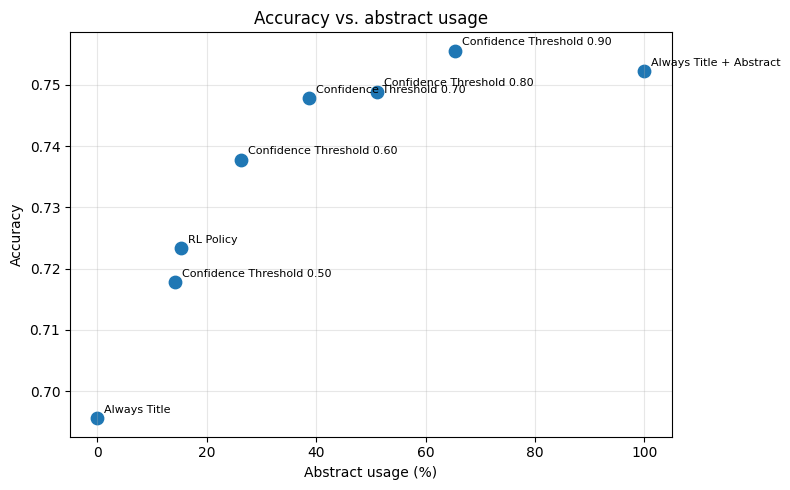

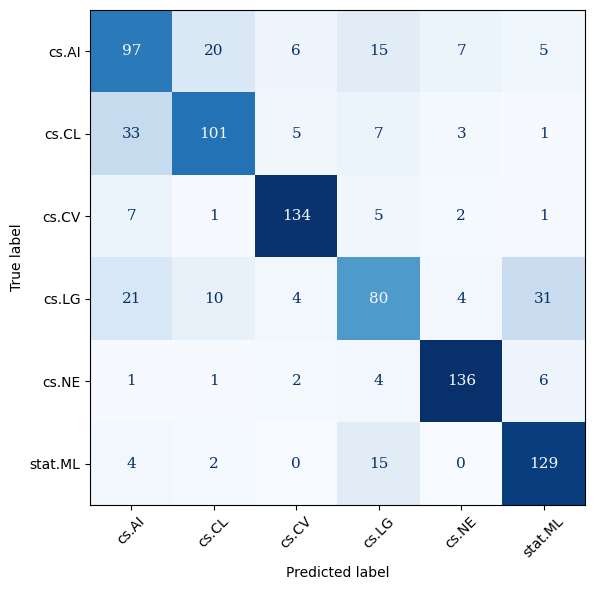

Classification report for best test model: ('SciBERT', 'title_abstract')
              precision    recall  f1-score   support

       cs.AI       0.60      0.65      0.62       150
       cs.CL       0.75      0.67      0.71       150
       cs.CV       0.89      0.89      0.89       150
       cs.LG       0.63      0.53      0.58       150
       cs.NE       0.89      0.91      0.90       150
     stat.ML       0.75      0.86      0.80       150

    accuracy                           0.75       900
   macro avg       0.75      0.75      0.75       900
weighted avg       0.75      0.75      0.75       900



In [48]:
print("Baseline results: test split")
display(baseline_results_df[baseline_results_df["split"] == "test"].sort_values("macro_f1", ascending=False))

classification_reports = {}
for (model_name, input_mode), store in prediction_store.items():
    report_key = f"{model_name} | {input_mode}"
    classification_reports[report_key] = classification_report(
        y_test,
        store["test_pred"],
        target_names=label_names,
        zero_division=0,
        output_dict=True,
    )
with open(TABLES_DIR / "classification_reports.json", "w", encoding="utf-8") as f:
    json.dump(classification_reports, f, indent=2)

print("RL comparison")
display(rl_results_df)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = rl_results_df.copy()
ax.scatter(plot_df["abstract_usage"] * 100, plot_df["accuracy"], s=80)
for _, row in plot_df.iterrows():
    ax.annotate(row["method"], (row["abstract_usage"] * 100, row["accuracy"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Abstract usage (%)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. abstract usage")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "accuracy_vs_abstract_usage.png", dpi=160)
plt.show()

best_test_row = baseline_results_df[baseline_results_df["split"] == "test"].sort_values("macro_f1", ascending=False).iloc[0]
best_key = (best_test_row["model"], best_test_row["input"])
best_pred = prediction_store[best_key]["test_pred"]
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 6))
with plt.rc_context({"font.family": "serif", "font.size": 11}):
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(
        ax=ax,
        xticks_rotation=45,
        colorbar=False,
        cmap="Blues",
        values_format="d",
        im_kw={"vmin": 0},
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

display_classification_report(y_test, best_pred, f"Classification report for best test model: {best_key}")


## 14. Final Conclusion


In [49]:
always_title = rl_results_df[rl_results_df["method"] == "Always Title"].iloc[0]
always_abs = rl_results_df[rl_results_df["method"] == "Always Title + Abstract"].iloc[0]
rl_policy = rl_results_df[rl_results_df["method"] == "RL Policy"].iloc[0]
 
accuracy_gap_vs_abstract = always_abs["accuracy"] - rl_policy["accuracy"]
abstract_savings = always_abs["abstract_usage"] - rl_policy["abstract_usage"]
reward_gain_vs_title = rl_policy["average_reward"] - always_title["average_reward"]

conclusion = f"""
### Conclusion

The supervised baselines compare cheap title-only prediction against more expensive title + abstract prediction. The RL stage then uses title-only confidence features to decide when the abstract is worth reading.

On the test set, the RL policy used abstracts for **{rl_policy['abstract_usage']:.1%}** of papers, compared with **100.0%** for always reading abstracts. Its accuracy was **{rl_policy['accuracy']:.3f}**, while always reading abstracts achieved **{always_abs['accuracy']:.3f}** and always using titles achieved **{always_title['accuracy']:.3f}**.

The RL policy's average reward was **{rl_policy['average_reward']:.3f}**. It saved **{abstract_savings:.1%}** abstract reads relative to always reading abstracts, with a small accuracy gap of **{accuracy_gap_vs_abstract:.3f}**.**.
"""
print(conclusion)

summary_path = TABLES_DIR / "final_summary.md"
summary_path.write_text(conclusion, encoding="utf-8")
print(f"Saved summary to {summary_path}")



### Conclusion

The supervised baselines compare cheap title-only prediction against more expensive title + abstract prediction. The RL stage then uses title-only confidence features to decide when the abstract is worth reading.

On the test set, the RL policy used abstracts for **15.2%** of papers, compared with **100.0%** for always reading abstracts. Its accuracy was **0.723**, while always reading abstracts achieved **0.752** and always using titles achieved **0.696**.

The RL policy's average reward was **0.701**. It saved **84.8%** abstract reads relative to always reading abstracts, with a small accuracy gap of **0.029**.**.

Saved summary to /home/dd/code/final_nlp_project/results/tables/final_summary.md
